# Module 1.4 — The Continuity Equation

**Why dedicate a full module to one equation?**
The continuity equation is two lines long and looks trivial. But $\nabla\cdot\mathbf{u}=0$ is the constraint that makes incompressible CFD hard. Every instability in the pressure solver, every checkerboard pressure mode, every diverging SIMPLE iteration — all of it traces back to this one equation not being satisfied properly.

Understanding it deeply now means every pressure-solver difficulty you encounter later will have a clear diagnosis.

**Roadmap:**
1. Derivation — where the equation comes from, physically
2. Incompressible form and what it means geometrically
3. The streamfunction — a tool that satisfies continuity automatically
4. Divergence-free vs. non-divergence-free fields — what they look like
5. Why incompressible pressure is not thermodynamic
6. Python: checking, enforcing, and visualising divergence

In [3]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Derivation — The Pipe Cross-Section Argument

### The highway analogy

Imagine a single-lane highway. At a given moment, the density of cars (cars per km) and their speed determine the **car flux** (cars per hour passing a point). If cars flow into a stretch of highway faster than they leave, density builds up — a traffic jam forms. If they leave faster, the stretch empties.

The continuity equation says exactly this for a fluid, with density replacing car density:

$$\underbrace{\frac{\partial \rho}{\partial t}}_{\substack{\text{density builds up}\\\text{or depletes}}} + \underbrace{\frac{\partial(\rho u)}{\partial x}}_{\substack{\text{gradient of mass flux}\\\text{(more leaving than entering)}}} = 0$$

### Step-by-step 3D derivation

Take a small rectangular control volume $\Delta x \times \Delta y \times \Delta z$.

**x-direction:** mass flux in minus mass flux out:
$$(\rho u)|_x \, \Delta y \Delta z \, \Delta t - (\rho u)|_{x+\Delta x} \, \Delta y \Delta z \, \Delta t \approx -\frac{\partial(\rho u)}{\partial x} \Delta x \Delta y \Delta z \Delta t$$

The same applies in $y$ and $z$. The total change in mass inside the CV must equal the net flux in:

$$\frac{\partial \rho}{\partial t} \Delta x \Delta y \Delta z = -\left(\frac{\partial(\rho u)}{\partial x} + \frac{\partial(\rho v)}{\partial y} + \frac{\partial(\rho w)}{\partial z}\right) \Delta x \Delta y \Delta z$$

Divide by $\Delta x \Delta y \Delta z$:

$$\boxed{\frac{\partial \rho}{\partial t} + \nabla \cdot (\rho \mathbf{u}) = 0}$$

No approximations. This is exact.

## 2. The Incompressible Form — What It Means Geometrically

### When is $\rho =$ const valid?

Expand $\nabla\cdot(\rho\mathbf{u}) = \rho\nabla\cdot\mathbf{u} + \mathbf{u}\cdot\nabla\rho$. If $\rho$ changes negligibly:

$$\nabla\cdot\mathbf{u} = 0$$

This is valid when:
- **Liquids** (water, oil): density varies less than 0.01% with typical pressure changes
- **Slow gases** ($M < 0.3$): density changes are smaller than 5% of the reference density
- **Non-buoyant flows**: temperature variations don't cause significant density changes

**Rule of thumb:** if the flow speed is less than 30% of the speed of sound, treat it as incompressible.

### Geometric interpretation

Consider a small fluid parcel (a tiny cube of fluid). As it moves:
- If $\nabla\cdot\mathbf{u} > 0$: the parcel is expanding (fluid diverges from it)
- If $\nabla\cdot\mathbf{u} < 0$: the parcel is compressing (fluid converges toward it)
- If $\nabla\cdot\mathbf{u} = 0$: the parcel's **volume is preserved** as it moves

Incompressible flow = every fluid parcel conserves its volume as it moves through the domain. Fluid can be stretched and sheared (changing shape), but not compressed or expanded.

### In 2D — the four-neighbour constraint

$$\frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} = 0$$

If flow accelerates in $x$ ($\partial u/\partial x > 0$, e.g. a converging channel), it **must** decelerate in $y$ ($\partial v/\partial y < 0$) to compensate. The two velocity components are **not independent** — they are tied together by this constraint. This is why solving incompressible N-S requires a separate step to enforce continuity (the pressure Poisson equation).

## 3. The Streamfunction — Automatic Continuity Satisfaction

### The clever trick

For 2D incompressible flow, define a scalar function $\psi(x, y)$ such that:

$$u = \frac{\partial \psi}{\partial y}, \qquad v = -\frac{\partial \psi}{\partial x}$$

Substituting into the continuity equation:

$$\frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} = \frac{\partial^2\psi}{\partial x \partial y} - \frac{\partial^2\psi}{\partial y \partial x} = 0 \checkmark$$

Any smooth $\psi$ automatically satisfies continuity. You can choose $\psi$ freely and always get a valid incompressible velocity field from it.

### Why streamlines are contours of $\psi$

Along a streamline, the velocity is tangent to the curve. The condition for a curve $f(x,y) = \text{const}$ to be a streamline is:

$$u \frac{\partial f}{\partial y} - v \frac{\partial f}{\partial x} = 0$$

Substituting $u = \partial\psi/\partial y$ and $v = -\partial\psi/\partial x$ shows that $f = \psi$ satisfies this exactly. **Contours of $\psi$ are streamlines.**

**Practical consequence:** when you visualise CFD results with `ax.contour(X, Y, psi, ...)`, you are plotting the exact streamlines of the flow. The spacing between streamlines tells you the speed — closely spaced streamlines = high velocity (by continuity, same mass must pass through a narrow gap).

### Physical meaning of $\psi$

The difference in $\psi$ between two streamlines equals the volumetric flow rate (per unit depth) between them:

$$Q_{1\to 2} = \psi_2 - \psi_1 \quad \text{[m²/s per unit depth]}$$

This is useful for computing flow rates directly from the visualisation.

=== Streamfunction verification ===
ψ = sin(πx)·sin(πy)
u = ∂ψ/∂y = π·sin(πx)·cos(πy)
v = -∂ψ/∂x = -π·cos(πx)·sin(πy)

Max |div(u)|: 3.86e-14
  → ~machine precision: any ψ gives a divergence-free field automatically

Flow rate between ψ=0 (walls) and ψ=max (centre streamline):
  Q = ψ_max - ψ_min = 0.9996 - -0.9996 = 1.9992 m²/s per unit depth


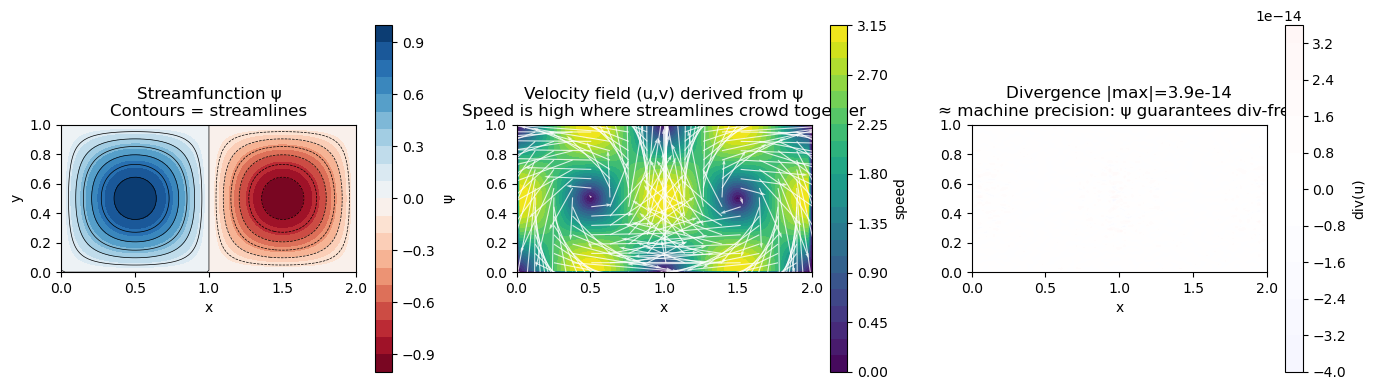

In [4]:
# ── The streamfunction in action ─────────────────────────────────────────────
# Start with an arbitrary streamfunction, derive u and v,
# then verify that div(u) = 0 exactly.

# ── Grid ────────────────────────────────────────────────────────────────────
N  = 80
x  = np.linspace(0, 2, N);   dx = x[1]-x[0]
y  = np.linspace(0, 1, N);   dy = y[1]-y[0]
X, Y = np.meshgrid(x, y)

# ── Choose a streamfunction (arbitrary smooth function) ─────────────────────
# ψ = sin(πx)·sin(πy): corresponds to a single vortex in a box
psi = np.sin(np.pi * X) * np.sin(np.pi * Y)

# ── Derive velocity from streamfunction ─────────────────────────────────────
# u = ∂ψ/∂y  (central differences)
# v = -∂ψ/∂x
U = np.zeros_like(psi)
V = np.zeros_like(psi)
U[1:-1, :] = (psi[2:, :] - psi[:-2, :]) / (2*dy)     # ∂ψ/∂y
V[:, 1:-1] = -(psi[:, 2:] - psi[:, :-2]) / (2*dx)    # -∂ψ/∂x

# ── Check divergence ────────────────────────────────────────────────────────
div = np.zeros_like(U)
div[1:-1, 1:-1] = ((U[1:-1, 2:] - U[1:-1, :-2]) / (2*dx) +
                   (V[2:, 1:-1] - V[:-2, 1:-1]) / (2*dy))

print('=== Streamfunction verification ===')
print(f'ψ = sin(πx)·sin(πy)')
print(f'u = ∂ψ/∂y = π·sin(πx)·cos(πy)')
print(f'v = -∂ψ/∂x = -π·cos(πx)·sin(πy)')
print()
print(f'Max |div(u)|: {np.max(np.abs(div[1:-1,1:-1])):.2e}')
print(f'  → ~machine precision: any ψ gives a divergence-free field automatically')
print()
print('Flow rate between ψ=0 (walls) and ψ=max (centre streamline):')
print(f'  Q = ψ_max - ψ_min = {psi.max():.4f} - {psi.min():.4f} = {psi.max()-psi.min():.4f} m²/s per unit depth')

# ── Visualise ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Streamfunction
cf = axes[0].contourf(X, Y, psi, levels=20, cmap='RdBu')
plt.colorbar(cf, ax=axes[0], label='ψ')
axes[0].contour(X, Y, psi, levels=15, colors='k', linewidths=0.5)
axes[0].set_title('Streamfunction ψ\nContours = streamlines'); axes[0].set_aspect('equal')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')

# Velocity field
speed = np.sqrt(U**2 + V**2)
skip = 5
cf2 = axes[1].contourf(X, Y, speed, levels=20, cmap='viridis')
plt.colorbar(cf2, ax=axes[1], label='speed')
axes[1].quiver(X[::skip,::skip], Y[::skip,::skip],
               U[::skip,::skip], V[::skip,::skip], color='white', alpha=0.8, scale=8)
axes[1].set_title('Velocity field (u,v) derived from ψ\nSpeed is high where streamlines crowd together')
axes[1].set_aspect('equal'); axes[1].set_xlabel('x')

# Divergence — should be ~zero
cf3 = axes[2].contourf(X, Y, div, levels=20, cmap='bwr', vmin=-1e-12, vmax=1e-12)
plt.colorbar(cf3, ax=axes[2], label='div(u)')
axes[2].set_title(f'Divergence |max|={np.max(np.abs(div[1:-1,1:-1])):.1e}\n≈ machine precision: ψ guarantees div-free')
axes[2].set_aspect('equal'); axes[2].set_xlabel('x')

plt.tight_layout()
plt.show()

## 4. Why Incompressible Pressure Is Not Thermodynamic

### The surprise

In compressible flow, pressure is a thermodynamic quantity: it comes from an equation of state ($p = \rho R T$ for an ideal gas). You compute $p$ from $\rho$ and $T$.

In incompressible flow, there is **no equation of state for pressure**. Density is constant and temperature (if energy is decoupled) is irrelevant to the momentum balance. So where does $p$ come from?

### Pressure as a constraint enforcer

Think of it this way: the momentum equation will give you a velocity field, but that velocity field will generally **not satisfy $\nabla\cdot\mathbf{u}=0$**. Pressure adjusts — instantaneously, infinitely fast — to correct the velocity so that it becomes divergence-free.

Mathematically, $p$ is a **Lagrange multiplier** that enforces the incompressibility constraint.

This is derived by taking the divergence of the momentum equation and using $\nabla\cdot\mathbf{u}=0$:

$$\nabla^2 p = -\rho \nabla\cdot[(\mathbf{u}\cdot\nabla)\mathbf{u}]$$

This is the **pressure Poisson equation** (Module 2.4). Given the velocity, solve this for $p$; then use $p$ to correct the velocity so it becomes divergence-free.

### Consequences

1. Pressure propagates at **infinite speed** in incompressible flow. A perturbation at one point is felt everywhere instantly. (In compressible flow it travels at the speed of sound.)

2. Pressure is determined only **up to an additive constant**. You must fix it at one point (or remove the mean) to get a unique solution.

3. Absolute pressure values don't matter — only **pressure gradients** drive the flow. You can shift $p$ by any constant without changing $\mathbf{u}$.

## Summary

| Concept | Key point |
|---------|----------|
| Continuity (general) | $\partial_t\rho + \nabla\cdot(\rho\mathbf{u})=0$ — mass is conserved in every CV |
| Incompressible form | $\nabla\cdot\mathbf{u}=0$ — valid for $M<0.3$, liquid flows |
| Geometric meaning | Every fluid parcel conserves its volume as it moves |
| Streamfunction | $u=\partial_y\psi$, $v=-\partial_x\psi$ — automatically div-free |
| Streamlines | Contours of $\psi$; close spacing = high speed |
| Incompressible pressure | A Lagrange multiplier, not thermodynamic; propagates at infinite speed |
| Pressure uniqueness | Only determined up to a constant — must be pinned at one point |

---
**Next:** Module 1.5 — Finite Difference Method: Taylor series, truncation error, and the stencils that discretise every derivative in this curriculum.

## Exercise

**Predict first, then verify.**

1. Is the velocity field $u = \cos(x)\sin(y)$, $v = \sin(x)\cos(y)$ incompressible? Compute $\partial u/\partial x + \partial v/\partial y$ analytically first, then verify numerically.

2. Construct a streamfunction $\psi = x^2 y - y^3/3$ (a classic corner flow). Derive $u$ and $v$, verify incompressibility, and plot the streamlines. What kind of flow does this represent?

3. For the streamfunction in part (2), compute the volumetric flow rate between the streamlines $\psi = 0$ and $\psi = 1$ at $x = 1$.